In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

### 2. Load Image Paths & Labels

In [2]:
DATASET_PATH = "dataset"

image_paths = []
labels = []

for class_name in os.listdir(DATASET_PATH):
    
    class_folder = os.path.join(DATASET_PATH, class_name)
    
    if not os.path.isdir(class_folder):
        continue
        
    for img in os.listdir(class_folder):
        
        path = os.path.join(class_folder, img)
        
        image_paths.append(path)
        labels.append(class_name)

print("Total Images:", len(image_paths))

Total Images: 4004


### CREATE DATAFRAME

In [3]:
df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

df.head()

,image_path,label
0,dataset\healthy\0001_0001.JPG,healthy
1,dataset\healthy\0001_0002.JPG,healthy
2,dataset\healthy\0001_0003.JPG,healthy
3,dataset\healthy\0001_0004.JPG,healthy
4,dataset\healthy\0001_0005.JPG,healthy


### Check Dataset

label
healthy      2129
unhealthy    1875
Name: count, dtype: int64


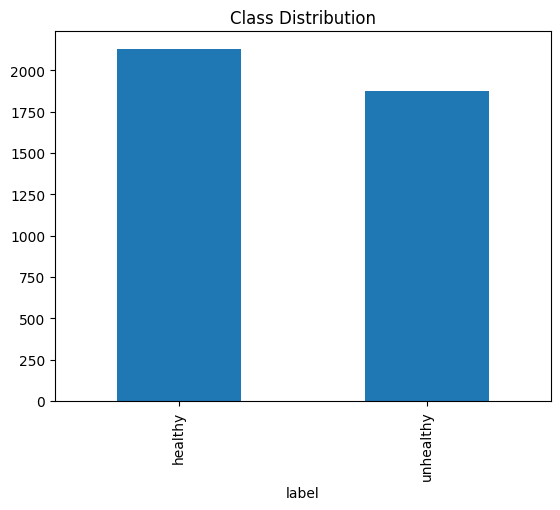

In [4]:
print(df["label"].value_counts())

df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()

### Dataset Information

In [5]:
df.info()

print("Dataset Shape:", df.shape)
print("Unique Classes:", df["label"].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4004 entries, 0 to 4003
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  4004 non-null   object
 1   label       4004 non-null   object
dtypes: object(2)
memory usage: 62.7+ KB
Dataset Shape: (4004, 2)
Unique Classes: 2


### 

### 4: Display Samples

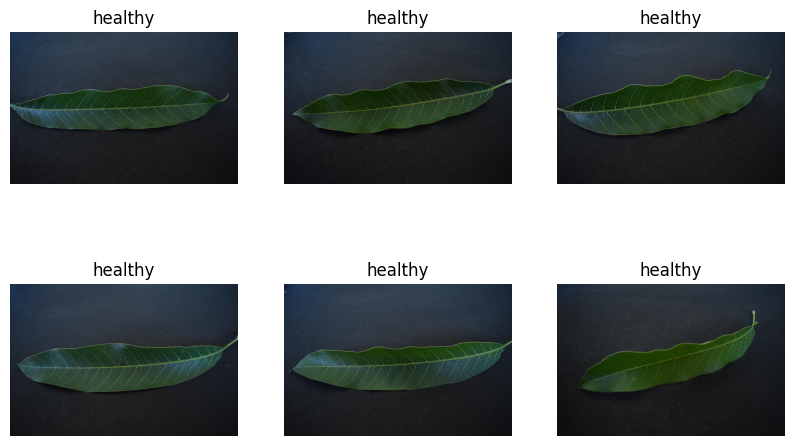

In [6]:
plt.figure(figsize=(10,6))

for i in range(6):

    img = cv2.imread(df.image_path[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(df.label[i])
    plt.axis("off")

plt.show()

### Dataset Statistics

In [7]:
print("Total images:", len(df))

counts = df['label'].value_counts()

print("Most common:", counts.index[0])
print("Least common:", counts.index[-1])
print("Average per class:", counts.mean())

counts

Total images: 4004
Most common: healthy
Least common: unhealthy
Average per class: 2002.0


label
healthy      2129
unhealthy    1875
Name: count, dtype: int64

### 5: Image Size Analysis

In [8]:
heights = []
widths = []

for path in df["image_path"][:200]:

    img = cv2.imread(path)

    if img is None:
        continue

    h,w,_ = img.shape
    heights.append(h)
    widths.append(w)

print("Avg Height:", np.mean(heights))
print("Avg Width:", np.mean(widths))

Avg Height: 4000.0
Avg Width: 6000.0


### 6: Train Test Split

In [9]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 3203
Test: 801


### 7: Label Encoding

In [10]:
le = LabelEncoder()

train_df["label_encoded"] = le.fit_transform(train_df["label"])
test_df["label_encoded"] = le.transform(test_df["label"])

print(le.classes_)

['healthy' 'unhealthy']


### 8: Image Preprocessing

In [11]:
def preprocess(path, size=(128,128)):

    img = cv2.imread(path)

    if img is None:
        return None

    img = cv2.resize(img, size)
    img = cv2.GaussianBlur(img,(5,5),0)

    return img

###  Save Processed Data Information

In [12]:
train_df.to_csv('train_data.csv', index=False)
test_df.to_csv('test_data.csv', index=False)

### Histogram Feature

In [13]:
def hist_feature(path):

    img = preprocess(path)

    if img is None:
        return None

    hist = cv2.calcHist([img],[0,1,2],None,[8,8,8],[0,256]*3)
    hist = cv2.normalize(hist,hist).flatten()

    return hist

### Edge Feature

In [14]:
def edge_feature(path):

    img = preprocess(path)

    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray,100,200)

    edges = cv2.resize(edges,(64,64))

    return edges.flatten()

### Combine Features

In [15]:
def extract_features(path):

    h = hist_feature(path)
    e = edge_feature(path)

    if h is None or e is None:
        return None

    features = np.hstack([h,e])

    return features

### Extract Features

In [ ]:
X = []
y = []

for _, row in train_df.iterrows():

    f = extract_features(row.image_path)

    if f is None:
        continue

    X.append(f)
    y.append(row.label_encoded)

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)

### Feature Scaling

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

### Train Nearest Mean Classifier

In [ ]:
class_means = {}

for c in np.unique(y):

    class_means[c] = X[y==c].mean(axis=0)

print("Classes trained:", class_means.keys())

### Prediction Function

In [ ]:
def predict_image(path):

    f = extract_features(path)

    f = scaler.transform([f])

    distances = {}

    for c in class_means:

        distances[c] = np.linalg.norm(f - class_means[c])

    pred = min(distances, key=distances.get)

    label = le.inverse_transform([pred])[0]

    return label

### Test Prediction

In [ ]:
sample = test_df.iloc[0]["image_path"]

img = cv2.imread(sample)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

print("Prediction:", predict_image(sample))

### Accuracy Check

In [22]:
correct = 0
total = 0

for _,row in test_df.iterrows():

    pred = predict_image(row.image_path)

    if pred == row.label: 
        correct += 1

    total += 1

print("Accuracy:", correct/total*100,"%")

Accuracy: 65.91760299625467 %
